# Extra — Estimativa de altitude com BMP180 e TensorFlow Lite Micro

Este notebook adapta o fluxo do *Hello World* para uma nova aplicação no ESP32-S3:

1. seleciona 500 cidades de forma estratificada em 10 faixas de altitude;
2. coleta temperatura e pressão históricas do Open-Meteo em um período de 42 dias;
3. mantém 1.000 observações distintas por cidade;
4. explora, limpa e separa cidades inteiras entre treino, validação e teste;
5. treina uma regressão para estimar altitude a partir de temperatura e pressão;
6. converte o modelo para TensorFlow Lite e para `int8` completo;
7. exporta o `.tflite`, `model_data.cc` e as constantes de normalização do firmware.

O resultado é uma demonstração acadêmica, não um altímetro certificado. A pressão também varia com o clima, por isso o modelo produz uma estimativa.


In [1]:
# Dependências usadas no Google Colab
!pip -q install tensorflow absl-py matplotlib pandas seaborn scikit-learn requests


## 1. Fonte e desenho do dataset

As cidades e suas coordenadas são obtidas do catálogo público [GeoNames `cities15000`](https://download.geonames.org/export/dump/). O catálogo é usado somente para localizar cidades candidatas. A altitude final é confirmada pela [Elevation API do Open-Meteo](https://open-meteo.com/en/docs/elevation-api), baseada no Copernicus DEM GLO-90.

Temperatura e pressão vêm da [Historical Weather API do Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api), sempre com o modelo `ERA5`. Para reduzir a coleta, são usados 42 dias, equivalentes a 1.008 horários, dos quais 1.000 são amostrados sem reposição por cidade.

As 500 localidades são distribuídas igualmente por 10 faixas de altitude. Em cada faixa, 35 cidades vão para treino e as 15 restantes são alternadas entre validação e teste. Assim, os conjuntos contêm 350, 75 e 75 cidades, respectivamente, sem compartilhar localidades.

As variáveis fornecidas ao modelo são somente:

- temperatura em graus Celsius;
- pressão, convertida de hPa para Pa;
- altitude em metros como valor esperado.

`timestamp`, `location`, `altitude_band` e `split` são mantidos apenas para auditoria e separação dos conjuntos. Eles não entram na rede neural.


In [2]:
from pathlib import Path
import io
import json
import math
import os
import random
import time
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import tensorflow as tf

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

HISTORICAL_API_URL = "https://archive-api.open-meteo.com/v1/archive"
ELEVATION_API_URL = "https://api.open-meteo.com/v1/elevation"
GEONAMES_URL = "https://download.geonames.org/export/dump/cities15000.zip"
HISTORICAL_MODEL = "era5"

# 42 dias = 1.008 horas; oito registros serão descartados por cidade.
START_DATE = "2023-04-01"
END_DATE = "2023-05-12"
ROWS_PER_LOCATION = 1000

ALTITUDE_BIN_EDGES = np.array(
    [-500, 100, 300, 500, 700, 900, 1200, 1600, 2000, 2500, 5000],
    dtype=np.float32,
)
ALTITUDE_LABELS = [
    "-500–99 m",
    "100–299 m",
    "300–499 m",
    "500–699 m",
    "700–899 m",
    "900–1199 m",
    "1200–1599 m",
    "1600–1999 m",
    "2000–2499 m",
    "2500–4999 m",
]

LOCATIONS_PER_BAND = 50
CANDIDATES_PER_BAND = 80
ELEVATION_BATCH_SIZE = 100
WEATHER_BATCH_SIZE = 50

# As pausas mantêm a coleta abaixo do limite público de chamadas por minuto.
ELEVATION_BATCH_PAUSE_SECONDS = 15
WEATHER_BATCH_PAUSE_SECONDS = 22

GEONAMES_COLUMNS = [
    "geonameid",
    "name",
    "asciiname",
    "alternatenames",
    "latitude",
    "longitude",
    "feature_class",
    "feature_code",
    "country_code",
    "cc2",
    "admin1_code",
    "admin2_code",
    "admin3_code",
    "admin4_code",
    "population",
    "elevation",
    "dem",
    "timezone",
    "modification_date",
]


def request_json_with_retry(url, params, timeout=240, max_attempts=6):
    """Consulta uma API e aguarda automaticamente em caso de HTTP 429."""
    for attempt in range(1, max_attempts + 1):
        response = requests.get(url, params=params, timeout=timeout)
        if response.status_code != 429:
            response.raise_for_status()
            return response.json()

        retry_after = response.headers.get("Retry-After")
        try:
            wait_seconds = max(65, int(float(retry_after)))
        except (TypeError, ValueError):
            wait_seconds = 65

        if attempt == max_attempts:
            response.raise_for_status()
        print(
            f"Limite temporário da API atingido; aguardando {wait_seconds} s "
            f"(tentativa {attempt}/{max_attempts})."
        )
        time.sleep(wait_seconds)

    raise RuntimeError("Não foi possível obter resposta da API.")


def haversine_km(latitude, longitude, other_latitudes, other_longitudes):
    latitude, longitude, other_latitudes, other_longitudes = map(
        np.radians,
        [latitude, longitude, other_latitudes, other_longitudes],
    )
    delta_latitude = other_latitudes - latitude
    delta_longitude = other_longitudes - longitude
    value = (
        np.sin(delta_latitude / 2) ** 2
        + np.cos(latitude)
        * np.cos(other_latitudes)
        * np.sin(delta_longitude / 2) ** 2
    )
    return 6371.0088 * 2 * np.arcsin(np.sqrt(value))


def diverse_location_sample(
    frame,
    sample_size,
    random_state,
    minimum_distance_km=30,
):
    """Favorece países diferentes e evita cidades quase coincidentes."""
    shuffled = frame.sample(frac=1.0, random_state=random_state).copy()
    shuffled["country_order"] = shuffled.groupby("country_code").cumcount()
    shuffled["random_order"] = np.random.default_rng(random_state).random(
        len(shuffled)
    )
    ordered = shuffled.sort_values(["country_order", "random_order"])

    selected_indices = []
    for minimum_distance in [minimum_distance_km, 15, 0]:
        for index, row in ordered.iterrows():
            if index in selected_indices:
                continue
            if selected_indices and minimum_distance > 0:
                selected = ordered.loc[selected_indices]
                distances = haversine_km(
                    row["latitude"],
                    row["longitude"],
                    selected["latitude"].to_numpy(),
                    selected["longitude"].to_numpy(),
                )
                if float(distances.min()) < minimum_distance:
                    continue
            selected_indices.append(index)
            if len(selected_indices) == sample_size:
                return (
                    ordered.loc[selected_indices]
                    .drop(columns=["country_order", "random_order"])
                    .reset_index(drop=True)
                )

    raise ValueError(
        f"Só foi possível selecionar {len(selected_indices)} de "
        f"{sample_size} localidades."
    )


print(f"TensorFlow: {tf.__version__}")
print(f"Modelo histórico: {HISTORICAL_MODEL}")
print(f"Período: {START_DATE} a {END_DATE}")
print(f"Localidades finais: {LOCATIONS_PER_BAND * len(ALTITUDE_LABELS)}")
print(f"Observações finais por localidade: {ROWS_PER_LOCATION}")


TensorFlow: 2.20.0
Modelo histórico: era5
Período: 2023-04-01 a 2023-05-12
Localidades finais: 500
Observações finais por localidade: 1000


## 2. Seleção estratificada e coleta

Primeiro, o notebook baixa o catálogo GeoNames e escolhe 80 candidatas por faixa, favorecendo países diferentes e evitando coordenadas muito próximas. As altitudes são então verificadas pela API de elevação do Open-Meteo. Somente depois dessa verificação são selecionadas exatamente 50 localidades por faixa.

As APIs aceitam várias coordenadas por requisição. As consultas são divididas em lotes e espaçadas para respeitar os limites do serviço público. Respostas HTTP 429 também recebem espera e nova tentativa automáticas.

Na coleta meteorológica, a elevação validada é enviada explicitamente ao Open-Meteo para que a pressão de superfície seja ajustada à mesma altitude usada como alvo. As unidades são verificadas antes da criação da tabela.


In [3]:
catalog_response = requests.get(GEONAMES_URL, timeout=180)
catalog_response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(catalog_response.content)) as archive:
    with archive.open("cities15000.txt") as source:
        city_catalog = pd.read_csv(
            source,
            sep="\t",
            names=GEONAMES_COLUMNS,
            low_memory=False,
        )

city_catalog["catalog_elevation_m"] = city_catalog["elevation"].fillna(
    city_catalog["dem"]
)
city_catalog = city_catalog.dropna(
    subset=[
        "geonameid",
        "name",
        "latitude",
        "longitude",
        "country_code",
        "catalog_elevation_m",
    ]
).copy()
city_catalog = city_catalog.drop_duplicates(subset="geonameid")
city_catalog = city_catalog.loc[
    city_catalog["catalog_elevation_m"].between(-500, 4999.999)
].copy()
city_catalog["catalog_band"] = pd.cut(
    city_catalog["catalog_elevation_m"],
    bins=ALTITUDE_BIN_EDGES,
    labels=ALTITUDE_LABELS,
    right=False,
)

catalog_counts = (
    city_catalog["catalog_band"]
    .value_counts(sort=False)
    .rename("catalog_cities")
    .to_frame()
)
display(catalog_counts)

candidate_parts = []
for band_index, band in enumerate(ALTITUDE_LABELS):
    lower = float(ALTITUDE_BIN_EDGES[band_index])
    upper = float(ALTITUDE_BIN_EDGES[band_index + 1])
    margin = min(50.0, (upper - lower) * 0.12)

    band_candidates = city_catalog.loc[
        (city_catalog["catalog_band"] == band)
        & (city_catalog["catalog_elevation_m"] >= lower + margin)
        & (city_catalog["catalog_elevation_m"] < upper - margin)
    ]
    if len(band_candidates) < CANDIDATES_PER_BAND:
        band_candidates = city_catalog.loc[
            city_catalog["catalog_band"] == band
        ]

    candidate_parts.append(
        diverse_location_sample(
            band_candidates,
            CANDIDATES_PER_BAND,
            RANDOM_SEED + band_index,
        )
    )

candidate_locations = pd.concat(candidate_parts, ignore_index=True)
print(
    f"Candidatas: {len(candidate_locations)} cidades de "
    f"{candidate_locations['country_code'].nunique()} países."
)

validated_elevations = []
for batch_start in range(
    0,
    len(candidate_locations),
    ELEVATION_BATCH_SIZE,
):
    batch = candidate_locations.iloc[
        batch_start : batch_start + ELEVATION_BATCH_SIZE
    ]
    elevation_payload = request_json_with_retry(
        ELEVATION_API_URL,
        params={
            "latitude": ",".join(batch["latitude"].astype(str)),
            "longitude": ",".join(batch["longitude"].astype(str)),
        },
    )
    batch_elevations = elevation_payload["elevation"]
    if len(batch_elevations) != len(batch):
        raise ValueError(
            f"A API de elevação retornou {len(batch_elevations)} valores, "
            f"mas {len(batch)} eram esperados."
        )
    validated_elevations.extend(float(value) for value in batch_elevations)

    if batch_start + ELEVATION_BATCH_SIZE < len(candidate_locations):
        time.sleep(ELEVATION_BATCH_PAUSE_SECONDS)

candidate_locations["altitude_m"] = validated_elevations
candidate_locations["altitude_band"] = pd.cut(
    candidate_locations["altitude_m"],
    bins=ALTITUDE_BIN_EDGES,
    labels=ALTITUDE_LABELS,
    right=False,
)

validated_counts = (
    candidate_locations["altitude_band"]
    .value_counts(sort=False)
    .rename("validated_candidates")
    .to_frame()
)
display(validated_counts)

if (validated_counts["validated_candidates"] < LOCATIONS_PER_BAND).any():
    insufficient = validated_counts.loc[
        validated_counts["validated_candidates"] < LOCATIONS_PER_BAND
    ]
    raise ValueError(
        "Não há candidatas validadas suficientes em todas as faixas:\n"
        f"{insufficient}"
    )

selected_parts = []
for band_index, band in enumerate(ALTITUDE_LABELS):
    band_candidates = candidate_locations.loc[
        candidate_locations["altitude_band"] == band
    ]
    selected = diverse_location_sample(
        band_candidates,
        LOCATIONS_PER_BAND,
        RANDOM_SEED + 100 + band_index,
    ).sample(frac=1.0, random_state=RANDOM_SEED + 200 + band_index)

    # 35 treino + 15 holdout. A oitava cidade alterna entre validação e teste.
    validation_count = 8 if band_index < 5 else 7
    test_count = 7 if band_index < 5 else 8
    selected["split"] = (
        ["train"] * 35
        + ["validation"] * validation_count
        + ["test"] * test_count
    )
    selected["altitude_band"] = band
    selected_parts.append(selected)

selected_locations = pd.concat(selected_parts, ignore_index=True)
selected_locations["location"] = selected_locations.apply(
    lambda row: (
        f"{row['name']} ({row['country_code']}-{int(row['geonameid'])})"
    ),
    axis=1,
)

LOCATIONS = selected_locations[
    [
        "location",
        "latitude",
        "longitude",
        "country_code",
        "altitude_m",
        "altitude_band",
        "split",
    ]
].to_dict("records")

assert len(LOCATIONS) == 500
assert selected_locations["location"].nunique() == 500
assert selected_locations["altitude_band"].value_counts().eq(50).all()
assert selected_locations["split"].value_counts().to_dict() == {
    "train": 350,
    "validation": 75,
    "test": 75,
}

selection_summary = (
    selected_locations.groupby(["altitude_band", "split"], observed=True)
    .agg(
        cities=("location", "nunique"),
        min_altitude_m=("altitude_m", "min"),
        max_altitude_m=("altitude_m", "max"),
    )
)
display(selection_summary)
print(
    f"Seleção final: {len(LOCATIONS)} cidades de "
    f"{selected_locations['country_code'].nunique()} países."
)


,catalog_cities
catalog_band,
-500–99 m,15317
100–299 m,8637
300–499 m,3344
500–699 m,1982
700–899 m,1217
900–1199 m,1167
1200–1599 m,1170
1600–1999 m,656
2000–2499 m,378


Candidatas: 800 cidades de 187 países.


,validated_candidates
altitude_band,
-500–99 m,83
100–299 m,80
300–499 m,78
500–699 m,81
700–899 m,81
900–1199 m,77
1200–1599 m,80
1600–1999 m,82
2000–2499 m,79


cities  min_altitude_m  max_altitude_m
altitude_band split                                             
-500–99 m     test             7             5.0            26.0
              train           35             0.0            50.0
              validation       8             2.0            51.0
100–299 m     test             7           130.0           263.0
              train           35           127.0           293.0
              validation       8           129.0           241.0
1200–1599 m   test             8          1247.0          1557.0
              train           35          1228.0          1521.0
              validation       7          1255.0          1410.0
1600–1999 m   test             8          1708.0          1941.0
              train           35          1644.0          1940.0
              validation       7          1648.0          1988.0
2000–2499 m   test             8          2074.0          2402.0
              train           35          2053.0          2412.0
              validation       7          2050.0          2331.0
2500–4999 m   test             8          2565.0          3828.0
              train           35          2538.0          4356.0
              validation       7          2561.0          3833.0
300–499 m     test             7           314.0           466.0
              train           35           312.0           471.0
              validation       8           324.0           436.0
500–699 m     test             7           530.0           614.0
              train           35           519.0           685.0
              validation       8           533.0           654.0
700–899 m     test             7           734.0           852.0
              train           35           722.0           875.0
              validation       8           728.0           818.0
900–1199 m    test             8           950.0          1144.0
              train           35           938.0          1154.0
              validation       7           932.0          1045.0

Seleção final: 500 cidades de 160 países.


In [4]:
payload = []

for batch_start in range(0, len(LOCATIONS), WEATHER_BATCH_SIZE):
    location_batch = LOCATIONS[
        batch_start : batch_start + WEATHER_BATCH_SIZE
    ]
    params = {
        "latitude": ",".join(str(item["latitude"]) for item in location_batch),
        "longitude": ",".join(str(item["longitude"]) for item in location_batch),
        "elevation": ",".join(str(item["altitude_m"]) for item in location_batch),
        "start_date": START_DATE,
        "end_date": END_DATE,
        "hourly": "temperature_2m,surface_pressure",
        "models": HISTORICAL_MODEL,
        "timezone": "UTC",
    }

    batch_payload = request_json_with_retry(
        HISTORICAL_API_URL,
        params=params,
    )
    if isinstance(batch_payload, dict):
        batch_payload = [batch_payload]

    if len(batch_payload) != len(location_batch):
        raise ValueError(
            f"O lote retornou {len(batch_payload)} localidades, "
            f"mas {len(location_batch)} eram esperadas."
        )

    payload.extend(batch_payload)
    completed = min(batch_start + WEATHER_BATCH_SIZE, len(LOCATIONS))
    print(f"Coleta: {completed}/{len(LOCATIONS)} localidades concluídas.")

    if batch_start + WEATHER_BATCH_SIZE < len(LOCATIONS):
        time.sleep(WEATHER_BATCH_PAUSE_SECONDS)

if len(payload) != len(LOCATIONS):
    raise ValueError(
        f"A API retornou {len(payload)} localidades, "
        f"mas {len(LOCATIONS)} eram esperadas."
    )

expected_hours = (
    pd.Timestamp(END_DATE) - pd.Timestamp(START_DATE)
).days * 24 + 24

frames = []
for location, item in zip(LOCATIONS, payload):
    units = item.get("hourly_units", {})
    temperature_unit = units.get("temperature_2m")
    pressure_unit = units.get("surface_pressure")

    if temperature_unit != "°C" or pressure_unit != "hPa":
        raise ValueError(
            f"Unidades inesperadas em {location['location']}: "
            f"temperatura={temperature_unit!r}, pressão={pressure_unit!r}."
        )

    hourly = item["hourly"]
    if len(hourly["time"]) != expected_hours:
        raise ValueError(
            f"{location['location']} retornou {len(hourly['time'])} horários; "
            f"eram esperados {expected_hours}."
        )

    frame = pd.DataFrame(
        {
            "timestamp": hourly["time"],
            "location": location["location"],
            "temperature_c": hourly["temperature_2m"],
            "pressure_hpa": hourly["surface_pressure"],
            "altitude_m": float(location["altitude_m"]),
            "split": location["split"],
        }
    )
    frames.append(frame)

raw_df = pd.concat(frames, ignore_index=True)
raw_df["timestamp"] = pd.to_datetime(raw_df["timestamp"], utc=True)

print(f"Requisições meteorológicas: {math.ceil(len(LOCATIONS) / WEATHER_BATCH_SIZE)}")
print(f"Linhas recebidas: {len(raw_df):,}")
display(raw_df.head())


Coleta: 50/500 localidades concluídas.
Coleta: 100/500 localidades concluídas.
Coleta: 150/500 localidades concluídas.
Coleta: 200/500 localidades concluídas.
Coleta: 250/500 localidades concluídas.
Coleta: 300/500 localidades concluídas.
Coleta: 350/500 localidades concluídas.
Coleta: 400/500 localidades concluídas.
Coleta: 450/500 localidades concluídas.
Coleta: 500/500 localidades concluídas.
Requisições meteorológicas: 10
Linhas recebidas: 504,000


,timestamp,location,temperature_c,pressure_hpa,altitude_m,split
0,2023-04-01 00:00:00+00:00,Massawa (ER-330546),24.4,1010.3,6.0,train
1,2023-04-01 01:00:00+00:00,Massawa (ER-330546),24.1,1010.5,6.0,train
2,2023-04-01 02:00:00+00:00,Massawa (ER-330546),23.7,1010.4,6.0,train
3,2023-04-01 03:00:00+00:00,Massawa (ER-330546),24.3,1011.2,6.0,train
4,2023-04-01 04:00:00+00:00,Massawa (ER-330546),24.4,1011.9,6.0,train


## 3. Exploração inicial

Antes da limpeza, são examinados formato, tipos, estatísticas, valores ausentes, duplicatas e distribuição por localidade. Isso permite documentar o que realmente veio da API, mesmo quando nenhum problema é encontrado.


In [5]:
quality_summary = pd.DataFrame(
    {
        "dtype": raw_df.dtypes.astype(str),
        "null_count": raw_df.isna().sum(),
        "null_percent": (raw_df.isna().mean() * 100).round(4),
        "unique_values": raw_df.nunique(),
    }
)

duplicate_count = raw_df.duplicated(
    subset=["timestamp", "location"]
).sum()

print(f"Formato do dataset: {raw_df.shape}")
print(f"Duplicatas de localidade + horário: {duplicate_count}")
display(quality_summary)
display(raw_df[["temperature_c", "pressure_hpa", "altitude_m"]].describe().T)

location_summary = (
    raw_df.groupby(["split", "location"], as_index=False)
    .agg(
        samples=("timestamp", "size"),
        altitude_m=("altitude_m", "first"),
        mean_temperature_c=("temperature_c", "mean"),
        mean_pressure_hpa=("pressure_hpa", "mean"),
    )
    .sort_values("altitude_m")
)
location_summary["altitude_band"] = pd.cut(
    location_summary["altitude_m"],
    bins=ALTITUDE_BIN_EDGES,
    labels=ALTITUDE_LABELS,
    right=False,
)

display(
    location_summary.groupby(["altitude_band", "split"], observed=True)
    .agg(
        cities=("location", "nunique"),
        min_altitude_m=("altitude_m", "min"),
        max_altitude_m=("altitude_m", "max"),
    )
)
display(location_summary.head(10))
display(location_summary.tail(10))


Formato do dataset: (504000, 6)
Duplicatas de localidade + horário: 0


,dtype,null_count,null_percent,unique_values
timestamp,"datetime64[ns, UTC]",0,0.0,1008
location,object,0,0.0,500
temperature_c,float64,0,0.0,635
pressure_hpa,float64,0,0.0,4245
altitude_m,float64,0,0.0,436
split,object,0,0.0,3


,count,mean,std,min,25%,50%,75%,max
temperature_c,504000.0,18.045010,8.592601,-22.0,12.30,18.5,24.400,45.3
pressure_hpa,504000.0,893.141375,91.510617,589.3,824.30,912.6,967.725,1035.1
altitude_m,504000.0,1142.680000,932.567278,0.0,400.75,903.5,1781.250,4356.0


cities  min_altitude_m  max_altitude_m
altitude_band split                                             
-500–99 m     test             7             5.0            26.0
              train           35             0.0            50.0
              validation       8             2.0            51.0
100–299 m     test             7           130.0           263.0
              train           35           127.0           293.0
              validation       8           129.0           241.0
300–499 m     test             7           314.0           466.0
              train           35           312.0           471.0
              validation       8           324.0           436.0
500–699 m     test             7           530.0           614.0
              train           35           519.0           685.0
              validation       8           533.0           654.0
700–899 m     test             7           734.0           852.0
              train           35           722.0           875.0
              validation       8           728.0           818.0
900–1199 m    test             8           950.0          1144.0
              train           35           938.0          1154.0
              validation       7           932.0          1045.0
1200–1599 m   test             8          1247.0          1557.0
              train           35          1228.0          1521.0
              validation       7          1255.0          1410.0
1600–1999 m   test             8          1708.0          1941.0
              train           35          1644.0          1940.0
              validation       7          1648.0          1988.0
2000–2499 m   test             8          2074.0          2402.0
              train           35          2053.0          2412.0
              validation       7          2050.0          2331.0
2500–4999 m   test             8          2565.0          3828.0
              train           35          2538.0          4356.0
              validation       7          2561.0          3833.0

,split,location,samples,altitude_m,mean_temperature_c,mean_pressure_hpa,altitude_band
176,train,Funafuti (TV-2110394),1008,0.0,27.739187,1009.498413,-500–99 m
487,validation,Smach Mean Chey (KH-8740221),1008,2.0,28.667163,1009.094147,-500–99 m
429,validation,As Saţwah (AE-385024),1008,3.0,27.157540,1009.019544,-500–99 m
293,train,Petit-Bourg (GP-3578682),1008,3.0,25.280060,1014.886012,-500–99 m
157,train,Dalap-Uliga-Dorrit (MH-8347657),1008,4.0,27.053175,1009.161310,-500–99 m
54,test,Puerto Cabello (VE-3629706),1008,5.0,27.289583,1011.633929,-500–99 m
68,test,Tønder (DK-2611497),1008,5.0,8.356250,1017.857341,-500–99 m
451,validation,Hlaingthaya (MM-8740157),1008,5.0,31.825595,1007.135218,-500–99 m
218,train,Kralendijk (BQ-3513563),1008,5.0,26.302183,1011.619147,-500–99 m
474,validation,Nuku‘alofa (TO-4032402),1008,6.0,25.648115,1012.468353,-500–99 m


,split,location,samples,altitude_m,mean_temperature_c,mean_pressure_hpa,altitude_band
478,validation,Padam (IN-1260942),1008,3562.0,-3.368353,664.470536,2500–4999 m
312,train,Quxu (CN-1279681),1008,3596.0,8.785516,664.694841,2500–4999 m
413,train,Yushu (CN-1281105),1008,3690.0,1.819444,653.102282,2500–4999 m
477,validation,Oruro (BO-3909234),1008,3704.0,11.202679,663.676389,2500–4999 m
44,test,Llallagua (BO-3911409),1008,3828.0,9.980556,653.679960,2500–4999 m
455,validation,Ilave (PE-3938451),1008,3833.0,9.759524,653.036012,2500–4999 m
304,train,Potosí (BO-3907584),1008,3962.0,8.561210,642.208234,2500–4999 m
178,train,Gar (CN-1280003),1008,4282.0,0.888095,611.580060,2500–4999 m
159,train,Damxung (CN-1281426),1008,4282.0,-1.791270,607.108234,2500–4999 m
148,train,Cerro de Pasco (PE-3944797),1008,4356.0,4.895139,613.673611,2500–4999 m


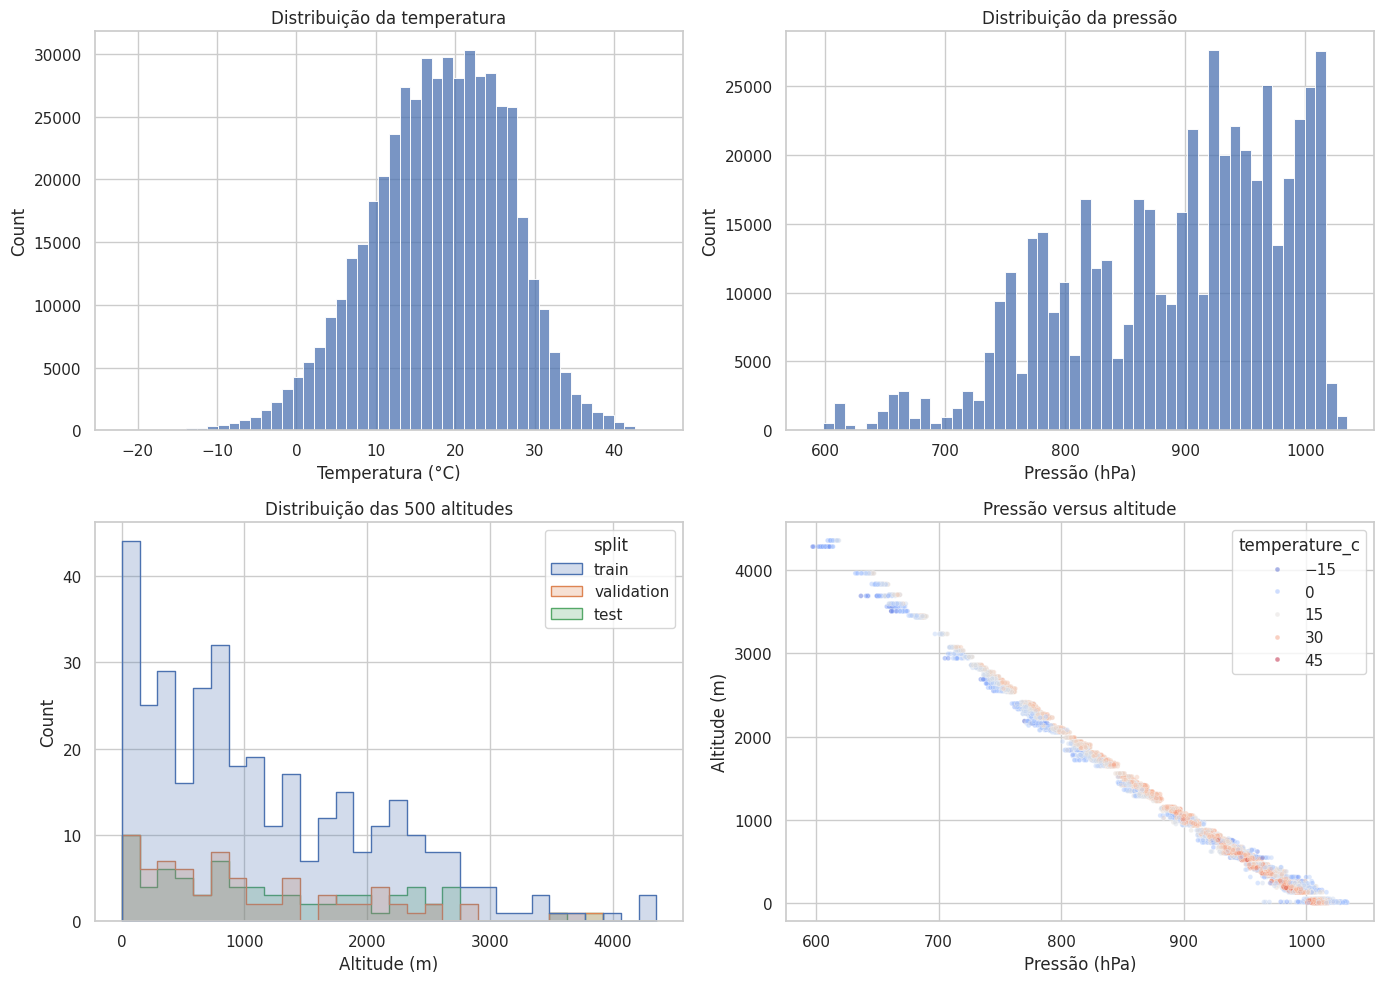

In [6]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(raw_df["temperature_c"], bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Distribuição da temperatura")
axes[0, 0].set_xlabel("Temperatura (°C)")

sns.histplot(raw_df["pressure_hpa"], bins=50, ax=axes[0, 1])
axes[0, 1].set_title("Distribuição da pressão")
axes[0, 1].set_xlabel("Pressão (hPa)")

sns.histplot(
    data=location_summary,
    x="altitude_m",
    hue="split",
    bins=30,
    element="step",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Distribuição das 500 altitudes")
axes[1, 0].set_xlabel("Altitude (m)")

plot_sample = raw_df.sample(min(10000, len(raw_df)), random_state=RANDOM_SEED)
sns.scatterplot(
    data=plot_sample,
    x="pressure_hpa",
    y="altitude_m",
    hue="temperature_c",
    palette="coolwarm",
    alpha=0.45,
    s=12,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Pressão versus altitude")
axes[1, 1].set_xlabel("Pressão (hPa)")
axes[1, 1].set_ylabel("Altitude (m)")

plt.tight_layout()
plt.show()


## 4. Limpeza, filtro e conversão de unidades

O tratamento executa somente operações justificadas pelo sensor e pela aplicação:

- mantém as colunas necessárias para modelagem e auditoria;
- remove linhas nulas e duplicatas de localidade/horário;
- aceita apenas temperatura entre −40 e 85 °C e pressão entre 300 e 1100 hPa, limites do BMP180 simulado;
- restringe a altitude ao intervalo definido para o experimento;
- converte pressão de hPa para Pa multiplicando por 100.

Valores meteorológicos extremos dentro desses limites não são removidos por IQR ou desvio-padrão, pois podem ser observações válidas.


In [7]:
selected_columns = [
    "timestamp",
    "location",
    "temperature_c",
    "pressure_hpa",
    "altitude_m",
    "split",
]

clean_df = raw_df[selected_columns].copy()
initial_rows = len(clean_df)

null_mask = clean_df[selected_columns].isna().any(axis=1)
null_rows = int(null_mask.sum())
clean_df = clean_df.loc[~null_mask].copy()

duplicate_mask = clean_df.duplicated(
    subset=["timestamp", "location"], keep="first"
)
duplicate_rows = int(duplicate_mask.sum())
clean_df = clean_df.loc[~duplicate_mask].copy()

physical_mask = (
    clean_df["temperature_c"].between(-40.0, 85.0)
    & clean_df["pressure_hpa"].between(300.0, 1100.0)
    & clean_df["altitude_m"].between(
        float(ALTITUDE_BIN_EDGES[0]),
        float(ALTITUDE_BIN_EDGES[-1]),
        inclusive="left",
    )
)
out_of_range_rows = int((~physical_mask).sum())
clean_df = clean_df.loc[physical_mask].copy()

# Open-Meteo entrega hPa; o BMP180 entrega Pa.
clean_df["pressure_pa"] = clean_df["pressure_hpa"] * 100.0
clean_df = clean_df.drop(columns="pressure_hpa")

clean_df["altitude_band"] = pd.cut(
    clean_df["altitude_m"],
    bins=ALTITUDE_BIN_EDGES,
    labels=ALTITUDE_LABELS,
    right=False,
)

cleaning_report = pd.Series(
    {
        "initial_rows": initial_rows,
        "removed_nulls": null_rows,
        "removed_duplicates": duplicate_rows,
        "removed_out_of_range": out_of_range_rows,
        "final_rows": len(clean_df),
    },
    name="rows",
)

display(cleaning_report.to_frame())
display(clean_df.head())
display(clean_df[["temperature_c", "pressure_pa", "altitude_m"]].describe().T)


,rows
initial_rows,504000
removed_nulls,0
removed_duplicates,0
removed_out_of_range,0
final_rows,504000


,timestamp,location,temperature_c,altitude_m,split,pressure_pa,altitude_band
0,2023-04-01 00:00:00+00:00,Massawa (ER-330546),24.4,6.0,train,101030.0,-500–99 m
1,2023-04-01 01:00:00+00:00,Massawa (ER-330546),24.1,6.0,train,101050.0,-500–99 m
2,2023-04-01 02:00:00+00:00,Massawa (ER-330546),23.7,6.0,train,101040.0,-500–99 m
3,2023-04-01 03:00:00+00:00,Massawa (ER-330546),24.3,6.0,train,101120.0,-500–99 m
4,2023-04-01 04:00:00+00:00,Massawa (ER-330546),24.4,6.0,train,101190.0,-500–99 m


,count,mean,std,min,25%,50%,75%,max
temperature_c,504000.0,18.04501,8.592601,-22.0,12.30,18.5,24.40,45.3
pressure_pa,504000.0,89314.13750,9151.061736,58930.0,82430.00,91260.0,96772.50,103510.0
altitude_m,504000.0,1142.68000,932.567278,0.0,400.75,903.5,1781.25,4356.0


## 5. Separação por localidade e amostragem estratificada

A separação foi definida antes do treinamento: nenhuma cidade pode aparecer em mais de um conjunto. Isso é mais rigoroso do que dividir linhas aleatoriamente, pois testa o modelo em localidades não vistas.

Cada localidade fornece exatamente 1.000 linhas diferentes, amostradas sem reposição. Como cada faixa contém a mesma quantidade de cidades e cada cidade tem o mesmo peso, o treino fica perfeitamente equilibrado por faixa. Validação e teste diferem em apenas uma cidade por faixa, alternadamente.


In [8]:
split_locations = {
    split_name: set(clean_df.loc[clean_df["split"] == split_name, "location"])
    for split_name in ["train", "validation", "test"]
}

assert split_locations["train"].isdisjoint(split_locations["validation"])
assert split_locations["train"].isdisjoint(split_locations["test"])
assert split_locations["validation"].isdisjoint(split_locations["test"])

expected_bands = set(ALTITUDE_LABELS)
for split_name in ["train", "validation", "test"]:
    present_bands = set(
        clean_df.loc[clean_df["split"] == split_name, "altitude_band"]
        .dropna()
        .astype(str)
    )
    if present_bands != expected_bands:
        raise ValueError(
            f"O conjunto {split_name!r} não contém todas as faixas: "
            f"{present_bands}."
        )

available_per_location = clean_df.groupby("location").size()
insufficient_locations = available_per_location.loc[
    available_per_location < ROWS_PER_LOCATION
]
if not insufficient_locations.empty:
    raise ValueError(
        "Algumas localidades ficaram com menos de "
        f"{ROWS_PER_LOCATION} registros após a limpeza:\n"
        f"{insufficient_locations}"
    )

sampled_parts = []
for index, (location, location_frame) in enumerate(
    clean_df.groupby("location", sort=True)
):
    sampled_parts.append(
        location_frame.sample(
            n=ROWS_PER_LOCATION,
            replace=False,
            random_state=RANDOM_SEED + index,
        )
    )

sampled_df = (
    pd.concat(sampled_parts, ignore_index=True)
    .sample(frac=1.0, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

train_df = sampled_df.loc[sampled_df["split"] == "train"].copy()
validation_df = sampled_df.loc[
    sampled_df["split"] == "validation"
].copy()
test_df = sampled_df.loc[sampled_df["split"] == "test"].copy()

expected_city_counts = {"train": 350, "validation": 75, "test": 75}
for split_name, frame in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    actual_city_count = frame["location"].nunique()
    if actual_city_count != expected_city_counts[split_name]:
        raise ValueError(
            f"{split_name}: {actual_city_count} cidades; "
            f"eram esperadas {expected_city_counts[split_name]}."
        )

    print(f"\n{split_name.upper()}: {len(frame):,} linhas")
    print(f"Cidades: {actual_city_count}")
    display(
        frame.groupby("altitude_band", observed=True)
        .agg(
            cities=("location", "nunique"),
            samples=("timestamp", "size"),
        )
    )



TRAIN: 350,000 linhas
Cidades: 350


,cities,samples
altitude_band,,
-500–99 m,35,35000
100–299 m,35,35000
300–499 m,35,35000
500–699 m,35,35000
700–899 m,35,35000
900–1199 m,35,35000
1200–1599 m,35,35000
1600–1999 m,35,35000
2000–2499 m,35,35000



VALIDATION: 75,000 linhas
Cidades: 75


,cities,samples
altitude_band,,
-500–99 m,8,8000
100–299 m,8,8000
300–499 m,8,8000
500–699 m,8,8000
700–899 m,8,8000
900–1199 m,7,7000
1200–1599 m,7,7000
1600–1999 m,7,7000
2000–2499 m,7,7000



TEST: 75,000 linhas
Cidades: 75


,cities,samples
altitude_band,,
-500–99 m,7,7000
100–299 m,7,7000
300–499 m,7,7000
500–699 m,7,7000
700–899 m,7,7000
900–1199 m,8,8000
1200–1599 m,8,8000
1600–1999 m,8,8000
2000–2499 m,8,8000


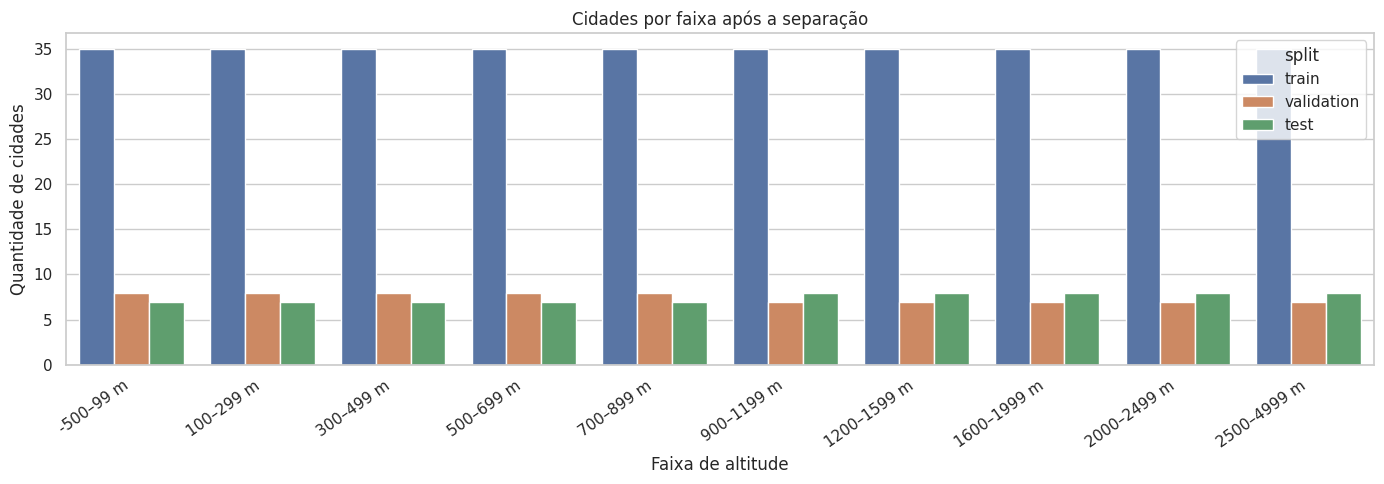

In [9]:
city_distribution = sampled_df[
    ["location", "split", "altitude_band"]
].drop_duplicates()

plt.figure(figsize=(14, 5))
sns.countplot(
    data=city_distribution,
    x="altitude_band",
    hue="split",
    order=ALTITUDE_LABELS,
)
plt.title("Cidades por faixa após a separação")
plt.xlabel("Faixa de altitude")
plt.ylabel("Quantidade de cidades")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 6. Normalização sem vazamento de dados

Médias e desvios-padrão são calculados **somente com o conjunto de treino**. Validação, teste e firmware reutilizam os mesmos números. Assim, informações das cidades reservadas não influenciam o treinamento.

A altitude também é normalizada durante o treinamento e convertida novamente para metros ao calcular as métricas.


In [10]:
FEATURES = ["temperature_c", "pressure_pa"]
TARGET = "altitude_m"

x_train = train_df[FEATURES].to_numpy(dtype=np.float32)
y_train = train_df[TARGET].to_numpy(dtype=np.float32).reshape(-1, 1)
x_validation = validation_df[FEATURES].to_numpy(dtype=np.float32)
y_validation = validation_df[TARGET].to_numpy(dtype=np.float32).reshape(-1, 1)
x_test = test_df[FEATURES].to_numpy(dtype=np.float32)
y_test = test_df[TARGET].to_numpy(dtype=np.float32).reshape(-1, 1)

input_mean = x_train.mean(axis=0).astype(np.float32)
input_std = x_train.std(axis=0).astype(np.float32)
target_mean = np.float32(y_train.mean())
target_std = np.float32(y_train.std())

if np.any(input_std == 0) or target_std == 0:
    raise ValueError("Desvio-padrão zero: não é possível normalizar os dados.")


def normalize_inputs(values):
    return ((values - input_mean) / input_std).astype(np.float32)


def normalize_target(values):
    return ((values - target_mean) / target_std).astype(np.float32)


def denormalize_target(values):
    return values * target_std + target_mean


x_train_norm = normalize_inputs(x_train)
x_validation_norm = normalize_inputs(x_validation)
x_test_norm = normalize_inputs(x_test)
y_train_norm = normalize_target(y_train)
y_validation_norm = normalize_target(y_validation)

normalization_table = pd.DataFrame(
    {
        "feature": FEATURES,
        "mean_from_train": input_mean,
        "std_from_train": input_std,
    }
)
display(normalization_table)
print(f"Altitude — média do treino: {target_mean:.3f} m")
print(f"Altitude — desvio do treino: {target_std:.3f} m")


,feature,mean_from_train,std_from_train
0,temperature_c,18.056572,8.676689
1,pressure_pa,89269.882812,9141.387695


Altitude — média do treino: 1145.254 m
Altitude — desvio do treino: 932.667 m


## 7. Treinamento

A rede é pequena para facilitar sua execução no ESP32-S3. A entrada tem dois valores normalizados e a saída é uma estimativa normalizada de altitude.


In [11]:
def create_model():
    model = tf.keras.Sequential(
        [
            tf.keras.Input(shape=(len(FEATURES),), name="environment_input"),
            tf.keras.layers.Dense(24, activation="relu", name="dense_1"),
            tf.keras.layers.Dense(16, activation="relu", name="dense_2"),
            tf.keras.layers.Dense(1, name="altitude_output"),
        ]
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"],
    )
    return model


model = create_model()
model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
    )
]

history = model.fit(
    x_train_norm,
    y_train_norm,
    validation_data=(x_validation_norm, y_validation_norm),
    epochs=100,
    batch_size=512,
    callbacks=callbacks,
    verbose=2,
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 24)             │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ altitude_output (Dense)         │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489 (1.91 KB)

 Trainable params: 489 (1.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
684/684 - 4s - 6ms/step - loss: 0.0344 - mae: 0.0895 - val_loss: 0.0019 - val_mae: 0.0332
Epoch 2/100
684/684 - 2s - 2ms/step - loss: 0.0018 - mae: 0.0313 - val_loss: 0.0016 - val_mae: 0.0302
Epoch 3/100
684/684 - 2s - 2ms/step - loss: 0.0017 - mae: 0.0303 - val_loss: 0.0015 - val_mae: 0.0297
Epoch 4/100
684/684 - 2s - 4ms/step - loss: 0.0017 - mae: 0.0301 - val_loss: 0.0015 - val_mae: 0.0296
Epoch 5/100
684/684 - 2s - 2ms/step - loss: 0.0017 - mae: 0.0300 - val_loss: 0.0015 - val_mae: 0.0295
Epoch 6/100
684/684 - 2s - 2ms/step - loss: 0.0017 - mae: 0.0300 - val_loss: 0.0015 - val_mae: 0.0291
Epoch 7/100
684/684 - 2s - 3ms/step - loss: 0.0017 - mae: 0.0299 - val_loss: 0.0015 - val_mae: 0.0290
Epoch 8/100
684/684 - 3s - 4ms/step - loss: 0.0017 - mae: 0.0299 - val_loss: 0.0015 - val_mae: 0.0291
Epoch 9/100
684/684 - 2s - 2ms/step - loss: 0.0017 - mae: 0.0299 - val_loss: 0.0015 - val_mae: 0.0292
Epoch 10/100
684/684 - 2s - 2ms/step - loss: 0.0017 - mae: 0.0299 - val_loss: 0.00

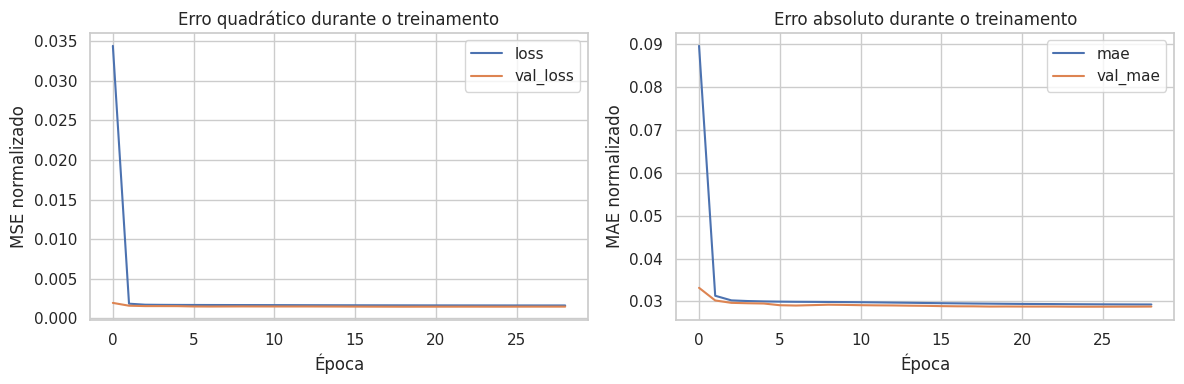

Keras: {'mae_m': 25.84983253479004, 'rmse_m': 34.847862243652344}


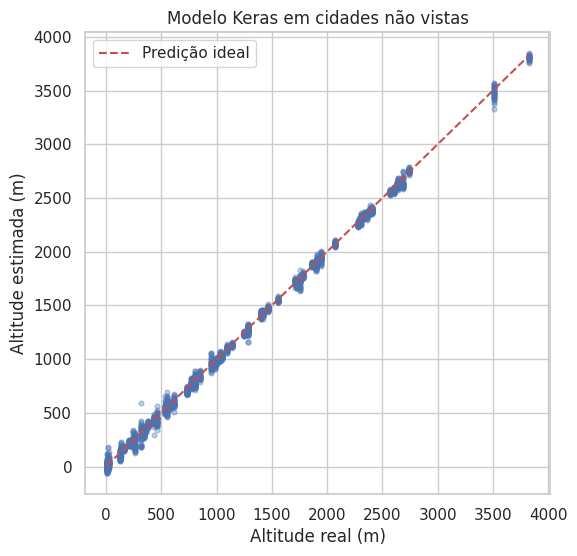

In [12]:
history_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_title("Erro quadrático durante o treinamento")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("MSE normalizado")

history_df[["mae", "val_mae"]].plot(ax=axes[1])
axes[1].set_title("Erro absoluto durante o treinamento")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MAE normalizado")
plt.tight_layout()
plt.show()


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=np.float32).reshape(-1)
    errors = y_pred - y_true
    return {
        "mae_m": float(np.mean(np.abs(errors))),
        "rmse_m": float(np.sqrt(np.mean(np.square(errors)))),
    }


keras_prediction_norm = model.predict(x_test_norm, verbose=0)
keras_prediction_m = denormalize_target(keras_prediction_norm)
keras_metrics = regression_metrics(y_test, keras_prediction_m)
print("Keras:", keras_metrics)

plot_count = min(2500, len(y_test))
plot_indices = np.random.default_rng(RANDOM_SEED).choice(
    len(y_test), size=plot_count, replace=False
)

plt.figure(figsize=(6, 6))
plt.scatter(
    y_test.reshape(-1)[plot_indices],
    keras_prediction_m.reshape(-1)[plot_indices],
    alpha=0.35,
    s=12,
)
limits = [float(y_test.min()), float(y_test.max())]
plt.plot(limits, limits, "r--", label="Predição ideal")
plt.xlabel("Altitude real (m)")
plt.ylabel("Altitude estimada (m)")
plt.title("Modelo Keras em cidades não vistas")
plt.legend()
plt.show()


## 8. Conversão para TensorFlow Lite e quantização `int8`

O modelo float é salvo para comparação. A versão final usa quantização inteira com um conjunto representativo retirado somente do treino normalizado.


In [13]:
OUTPUT_DIR = Path("/content/extra_altitude_models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FLOAT_MODEL_PATH = OUTPUT_DIR / "extra_altitude_float.tflite"
INT8_MODEL_PATH = OUTPUT_DIR / "extra_altitude_int8.tflite"

float_converter = tf.lite.TFLiteConverter.from_keras_model(model)
float_tflite_model = float_converter.convert()
FLOAT_MODEL_PATH.write_bytes(float_tflite_model)

representative_rng = np.random.default_rng(RANDOM_SEED)
representative_indices = representative_rng.choice(
    len(x_train_norm),
    size=min(1000, len(x_train_norm)),
    replace=False,
)


def representative_dataset():
    for index in representative_indices:
        yield [x_train_norm[index : index + 1].astype(np.float32)]


int8_converter = tf.lite.TFLiteConverter.from_keras_model(model)
int8_converter.optimizations = [tf.lite.Optimize.DEFAULT]
int8_converter.representative_dataset = representative_dataset
int8_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
int8_converter.inference_input_type = tf.int8
int8_converter.inference_output_type = tf.int8
int8_tflite_model = int8_converter.convert()
INT8_MODEL_PATH.write_bytes(int8_tflite_model)

print(f"Modelo float: {FLOAT_MODEL_PATH} ({FLOAT_MODEL_PATH.stat().st_size:,} bytes)")
print(f"Modelo int8 : {INT8_MODEL_PATH} ({INT8_MODEL_PATH.stat().st_size:,} bytes)")


Saved artifact at '/tmp/tmpjkw1rzqk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='environment_input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137071841145296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137071841143952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137071841145488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137071841145872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137071841137040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137071841145680: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved artifact at '/tmp/tmp0sl4eac4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='environment_input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137071841145296: Ten

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


## 9. Avaliação dos modelos TFLite

Na versão quantizada, a entrada normalizada é convertida para `int8`. A saída bruta também é `int8`; para calcular altitude e métricas, ela é desquantizada sem realizar subtração em `np.int8`, evitando overflow.


In [14]:
def quantize_tensor(values, details):
    values = np.asarray(values, dtype=np.float32)
    dtype = details["dtype"]
    scale, zero_point = details.get("quantization", (0.0, 0))

    if dtype in (np.int8, np.uint8):
        if scale in (0, 0.0):
            raise ValueError("Tensor inteiro sem escala de quantização válida.")
        quantized = np.round(values / float(scale) + int(zero_point))
        dtype_info = np.iinfo(dtype)
        return np.clip(quantized, dtype_info.min, dtype_info.max).astype(dtype)

    return values.astype(dtype)


def dequantize_tensor(values, details):
    raw_values = np.asarray(values)
    dtype = details["dtype"]
    scale, zero_point = details.get("quantization", (0.0, 0))

    if dtype in (np.int8, np.uint8):
        if scale in (0, 0.0):
            raise ValueError("Tensor inteiro sem escala de quantização válida.")
        return (
            raw_values.astype(np.int32) - int(zero_point)
        ).astype(np.float32) * float(scale)

    return raw_values.astype(np.float32)


def predict_tflite(model_path, normalized_inputs, batch_size=1024):
    interpreter = tf.lite.Interpreter(model_path=str(model_path))
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    predictions = np.empty((len(normalized_inputs), 1), dtype=np.float32)

    for start in range(0, len(normalized_inputs), batch_size):
        batch = normalized_inputs[start : start + batch_size]
        interpreter.resize_tensor_input(
            input_index,
            [len(batch), batch.shape[1]],
            strict=False,
        )
        interpreter.allocate_tensors()
        input_details = interpreter.get_input_details()[0]
        output_details = interpreter.get_output_details()[0]

        interpreter.set_tensor(
            input_details["index"],
            quantize_tensor(batch, input_details),
        )
        interpreter.invoke()
        raw_output = interpreter.get_tensor(output_details["index"])
        predictions[start : start + len(batch)] = dequantize_tensor(
            raw_output,
            output_details,
        ).reshape(-1, 1)

    return predictions, input_details, output_details


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,model,mae_m,rmse_m
0,Keras,25.849833,34.847862
1,TFLite float,25.849833,34.847866
2,TFLite int8,26.800362,35.716911


Entrada float: {'name': 'serving_default_environment_input:0', 'index': 0, 'shape': array([248,   2], dtype=int32), 'shape_signature': array([-1,  2], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
Saída float: {'name': 'StatefulPartitionedCall_1:0', 'index': 9, 'shape': array([248,   1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
Entrada int8: {'name': 'serving_default_environment_input:0', 'index': 0, 'shape': array([248,   2], dtype=int32), 'shape_signature': array([-1,  2], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.023882174864411354, 5), 'quantiz

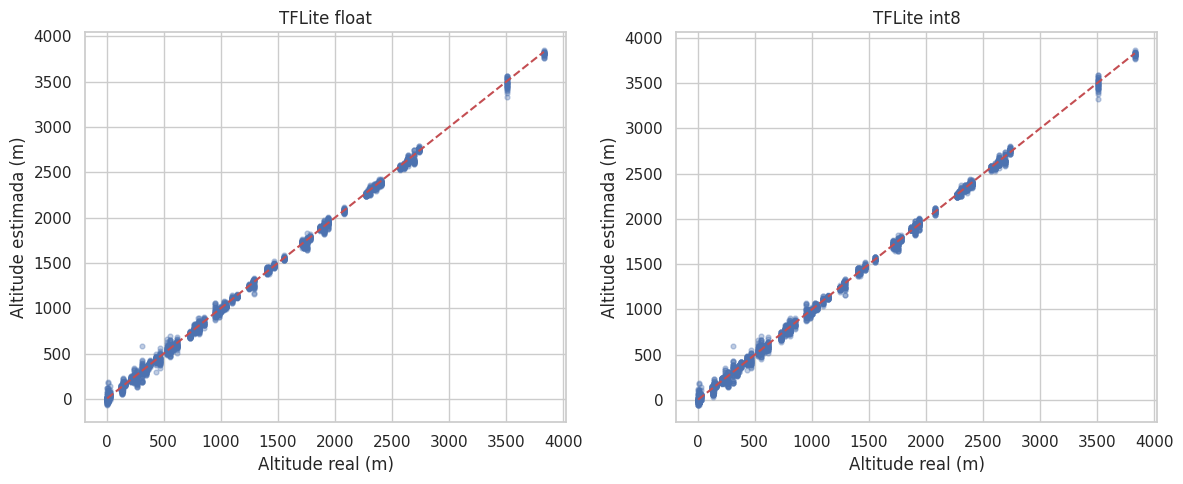

In [15]:
float_prediction_norm, float_input_details, float_output_details = predict_tflite(
    FLOAT_MODEL_PATH, x_test_norm
)
int8_prediction_norm, int8_input_details, int8_output_details = predict_tflite(
    INT8_MODEL_PATH, x_test_norm
)

float_prediction_m = denormalize_target(float_prediction_norm)
int8_prediction_m = denormalize_target(int8_prediction_norm)

float_metrics = regression_metrics(y_test, float_prediction_m)
int8_metrics = regression_metrics(y_test, int8_prediction_m)

comparison = pd.DataFrame(
    [
        {"model": "Keras", **keras_metrics},
        {"model": "TFLite float", **float_metrics},
        {"model": "TFLite int8", **int8_metrics},
    ]
)
display(comparison)

print("Entrada float:", float_input_details)
print("Saída float:", float_output_details)
print("Entrada int8:", int8_input_details)
print("Saída int8:", int8_output_details)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, predictions, title in [
    (axes[0], float_prediction_m, "TFLite float"),
    (axes[1], int8_prediction_m, "TFLite int8"),
]:
    axis.scatter(
        y_test.reshape(-1)[plot_indices],
        predictions.reshape(-1)[plot_indices],
        alpha=0.35,
        s=12,
    )
    axis.plot(limits, limits, "r--")
    axis.set_title(title)
    axis.set_xlabel("Altitude real (m)")
    axis.set_ylabel("Altitude estimada (m)")
plt.tight_layout()
plt.show()


## 10. Exportação para o firmware

Além do `.tflite`, o firmware precisa das médias e desvios usados na normalização. O cabeçalho gerado registra a ordem das entradas:

1. temperatura em °C;
2. pressão em Pa.

O `model_data.cc` é gravado diretamente em UTF-8, com os símbolos `g_model` e `g_model_len`, `const` e `alignas(8)`.


In [16]:
PREPROCESSING_JSON_PATH = OUTPUT_DIR / "extra_altitude_preprocessing.json"
NORMALIZATION_HEADER_PATH = OUTPUT_DIR / "extra_altitude_normalization.h"
MODEL_DATA_PATH = OUTPUT_DIR / "model_data.cc"
BALANCED_DATASET_PATH = OUTPUT_DIR / "extra_altitude_dataset_balanced.csv"

preprocessing = {
    "location_catalog": GEONAMES_URL,
    "elevation_source": ELEVATION_API_URL,
    "historical_model": HISTORICAL_MODEL,
    "period": {"start": START_DATE, "end": END_DATE},
    "rows_per_location": ROWS_PER_LOCATION,
    "altitude_bin_edges_m": [float(value) for value in ALTITUDE_BIN_EDGES],
    "altitude_band_labels": ALTITUDE_LABELS,
    "random_seed": RANDOM_SEED,
    "features": FEATURES,
    "feature_units": ["degC", "Pa"],
    "input_mean": [float(value) for value in input_mean],
    "input_std": [float(value) for value in input_std],
    "target": TARGET,
    "target_unit": "m",
    "target_mean": float(target_mean),
    "target_std": float(target_std),
    "train_locations": sorted(split_locations["train"]),
    "validation_locations": sorted(split_locations["validation"]),
    "test_locations": sorted(split_locations["test"]),
}
PREPROCESSING_JSON_PATH.write_text(
    json.dumps(preprocessing, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

normalization_header = f'''#pragma once

// Input order: temperature (degC), pressure (Pa).
constexpr float kAltitudeInputMean[2] = {{{input_mean[0]:.9g}f, {input_mean[1]:.9g}f}};
constexpr float kAltitudeInputStd[2] = {{{input_std[0]:.9g}f, {input_std[1]:.9g}f}};
constexpr float kAltitudeTargetMean = {target_mean:.9g}f;
constexpr float kAltitudeTargetStd = {target_std:.9g}f;
'''
NORMALIZATION_HEADER_PATH.write_text(normalization_header, encoding="utf-8")

model_bytes = INT8_MODEL_PATH.read_bytes()
hex_values = [f"0x{value:02x}" for value in model_bytes]
array_lines = [
    "  " + ", ".join(hex_values[index : index + 12])
    for index in range(0, len(hex_values), 12)
]
model_data_source = (
    '#include "model_data.h"\n\n'
    "alignas(8) const unsigned char g_model[] = {\n"
    + ",\n".join(array_lines)
    + "\n};\n\n"
    + "const int g_model_len = sizeof(g_model);\n"
)
MODEL_DATA_PATH.write_text(model_data_source, encoding="utf-8", newline="\n")

balanced_dataset = pd.concat(
    [train_df, validation_df, test_df], ignore_index=True
).sort_values(["split", "location", "timestamp"])
balanced_dataset.to_csv(BALANCED_DATASET_PATH, index=False)

artifacts = [
    FLOAT_MODEL_PATH,
    INT8_MODEL_PATH,
    PREPROCESSING_JSON_PATH,
    NORMALIZATION_HEADER_PATH,
    MODEL_DATA_PATH,
    BALANCED_DATASET_PATH,
]
display(
    pd.DataFrame(
        {
            "file": [path.name for path in artifacts],
            "bytes": [path.stat().st_size for path in artifacts],
        }
    )
)


,file,bytes
0,extra_altitude_float.tflite,3860
1,extra_altitude_int8.tflite,3736
2,extra_altitude_preprocessing.json,15902
3,extra_altitude_normalization.h,299
4,model_data.cc,23154
5,extra_altitude_dataset_balanced.csv,43693883


In [17]:
# Execute esta célula quando quiser baixar os artefatos do Colab.
from google.colab import files

for artifact in [
    INT8_MODEL_PATH,
    PREPROCESSING_JSON_PATH,
    NORMALIZATION_HEADER_PATH,
    MODEL_DATA_PATH,
]:
    files.download(str(artifact))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Próximos passos no ESP32-S3

No firmware:

1. ler temperatura e pressão do BMP180 pelo I2C;
2. manter a pressão em Pa, como entregue pelo sensor;
3. normalizar as duas entradas com `extra_altitude_normalization.h`;
4. quantizar cada entrada usando `input->params.scale` e `input->params.zero_point`;
5. executar a inferência;
6. desquantizar a saída e desfazer a normalização da altitude;
7. imprimir temperatura, pressão e altitude estimada no monitor serial.

Como a rede e a entrada mudaram, o tamanho da arena de tensores deve ser medido novamente durante a integração.
